⚖️ STEP 1: CALCULATING ASSOCIATION RULES FROM MATRIX...
✔️ Successfully extracted 116 association rules.

🎨 STEP 2: GENERATING UNIQUE NETWORK GRAPH VISUALIZATION...


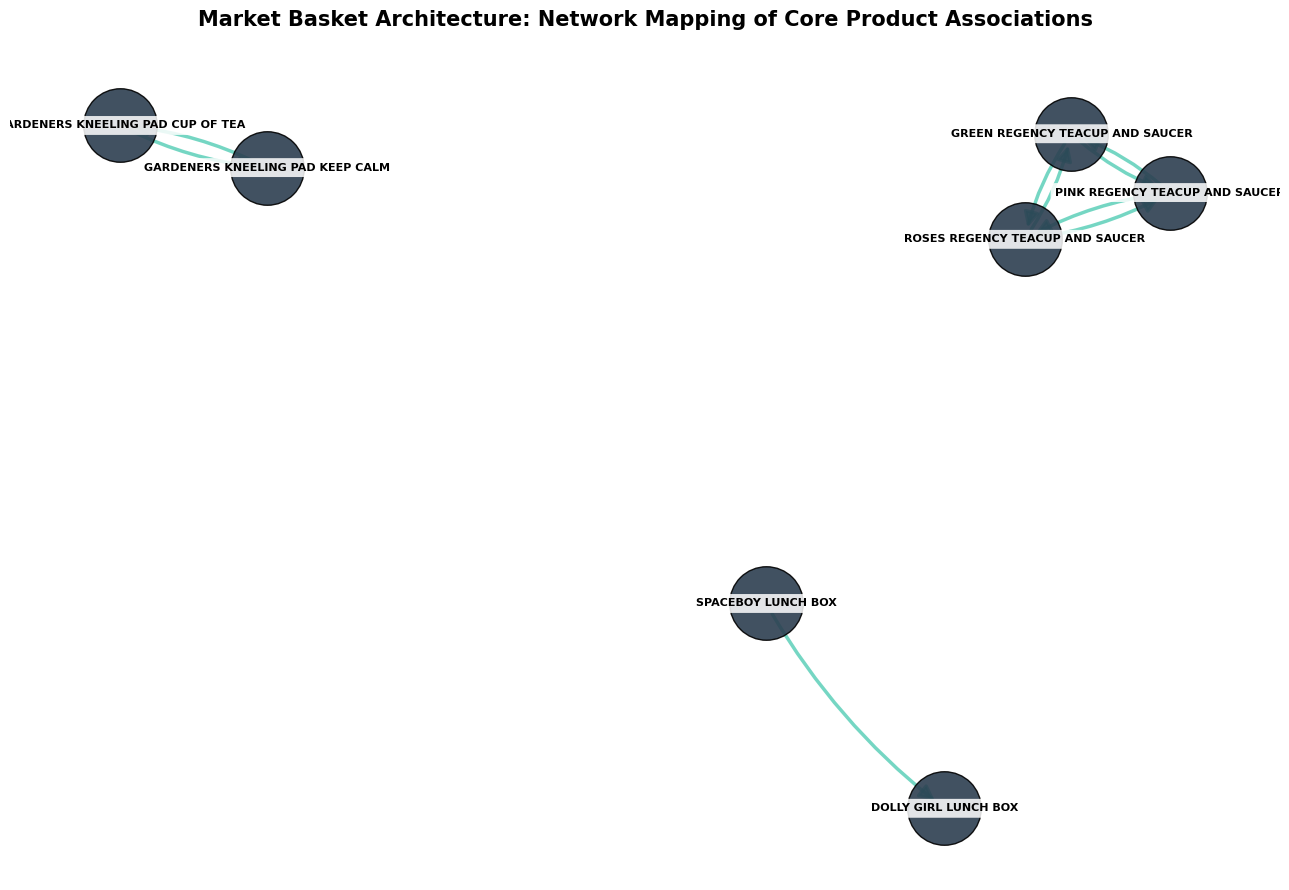

✔️ Network diagram successfully generated and saved as 'real_market_basket_rules.png'!


In [4]:
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore")

print("⚖️ STEP 1: CALCULATING ASSOCIATION RULES FROM MATRIX...")
# Make sure the frequent itemsets are generated using our optimized matrix
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)

# Generate rules based on statistical Lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by="lift", ascending=False).reset_index(drop=True)
print(f"✔️ Successfully extracted {len(rules)} association rules.")

print("\n🎨 STEP 2: GENERATING UNIQUE NETWORK GRAPH VISUALIZATION...")
# Extract the top 15 strongest rules to keep the graph clean and readable
top_rules = rules.head(15)

# Initialize the network graph
G = nx.DiGraph()

# Populate nodes and lines from the rules
for idx, row in top_rules.iterrows():
    source = list(row['antecedents'])[0]
    target = list(row['consequents'])[0]
    weight = row['lift']
    G.add_edge(source, target, weight=weight)

# Establish structural physics layout
plt.figure(figsize=(13, 9))
pos = nx.spring_layout(G, k=1.3, seed=42)

# Draw the architectural network components
nx.draw_networkx_nodes(G, pos, node_size=2800, node_color='#2C3E50', edgecolors='black', alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2.5, alpha=0.6, edge_color='#1ABC9C', arrowsize=22, connectionstyle="arc3,rad=0.1")

# Overlay the product labels cleanly above the nodes
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', font_color='black',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, boxstyle='round,pad=0.4'))

plt.title('Market Basket Architecture: Network Mapping of Core Product Associations', fontsize=15, fontweight='bold', pad=20)
plt.axis('off')

plt.tight_layout()
plt.savefig('real_market_basket_rules.png', dpi=300)
plt.show()
print("✔️ Network diagram successfully generated and saved as 'real_market_basket_rules.png'!")